# Canadian Building Permits Live Tracker
### Live data pipeline: Statistics Canada API &rarr; Python (Jupyter) &rarr; SQL &rarr; Power BI

**What this notebook does**
1. Pulls the **live** Building Permits table (34-10-0066-01) directly from Statistics Canada's public Web Data Service (WDS) API — no key required
2. Cleans and filters it down to national + provincial monthly permit values
3. Analyzes trends using three different techniques: rolling/YoY comparison (pandas), seasonal decomposition (statsmodels), and a short-term trend forecast (scikit-learn)
4. Exports to **CSV** and a **SQLite database** for SQL querying and Power BI
5. Produces exploratory charts

> New to live APIs? Read `StatCan_Tracker_Explainer.pdf` alongside this notebook for a plain-language walkthrough.
> Want to see how an analyst reasons through this end-to-end? Read `Analyst_Thought_Process.pdf`.

**Data source:** Statistics Canada, Table 34-10-0066-01 — "Building permits, by type of structure and type of work" (monthly) — accessed via the public WDS API, https://www.statcan.gc.ca/en/developers/wds


## 1. Setup

No API key is needed for StatCan's WDS — it's a fully open public API. That makes this a
good "first live API" project, since you skip the signup/authentication step entirely and
go straight to the request &rarr; response &rarr; DataFrame pattern.

If any package is missing, run once in a terminal:
```
pip install requests pandas numpy matplotlib statsmodels scikit-learn
```


In [1]:
import requests
import pandas as pd
import numpy as np
import sqlite3
import zipfile
import io
from datetime import datetime

pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


## 2. Configuration

`PRODUCT_ID` is StatCan's identifier for the Building Permits table (34-10-0066-01, written
without dashes and the trailing check digit). You can swap this for any other StatCan table
by finding its number on https://www150.statcan.gc.ca and using the same 8-digit product ID.

As with the AESO project, `USE_LIVE_API` lets you test the full pipeline before you've
confirmed live access — sample data has the identical structure to the real thing.


In [2]:
PRODUCT_ID = "34100066"   # StatCan Table 34-10-0066-01: Building permits
USE_LIVE_API = False       # set to True to pull the real, current StatCan table

# Provinces/regions to keep after filtering (national total is always kept)
REGIONS_OF_INTEREST = ["Canada", "Alberta", "Ontario", "British Columbia", "Quebec"]

print(f"Live API mode: {USE_LIVE_API}")
print(f"Regions tracked: {REGIONS_OF_INTEREST}")


Live API mode: False
Regions tracked: ['Canada', 'Alberta', 'Ontario', 'British Columbia', 'Quebec']


## 3. Pull function

StatCan's "full table download" endpoint works in two steps, which is a common API pattern
worth recognizing:
1. You call the WDS API asking for a download link for a given table
2. The API replies with a URL (a ZIP file containing the full table as CSV + metadata)
3. You download and unzip that file yourself

This two-step "ask for a link, then fetch it" pattern shows up constantly in real APIs
(cloud storage, reporting exports, etc.) — it's worth understanding, not just copying.


In [3]:
def get_statcan_table(product_id):
    # Step 1: ask StatCan for the current download link for this table
    link_url = f"https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/{product_id}/en"
    response = requests.get(link_url, timeout=30)
    response.raise_for_status()
    payload = response.json()

    if payload.get("status") != "SUCCESS":
        raise RuntimeError(f"StatCan API did not return success: {payload}")

    zip_url = payload["object"]
    print(f"Live download link received: {zip_url}")

    # Step 2: download the ZIP file
    zip_response = requests.get(zip_url, timeout=120)
    zip_response.raise_for_status()

    # Step 3: unzip in-memory and load the main data CSV (StatCan names it {product_id}.csv)
    with zipfile.ZipFile(io.BytesIO(zip_response.content)) as z:
        data_filename = [n for n in z.namelist() if n.endswith(".csv") and "MetaData" not in n][0]
        with z.open(data_filename) as f:
            df = pd.read_csv(f, low_memory=False)

    return df

print("Pull function ready.")


Pull function ready.


## 4. Sample-data generator (used only when `USE_LIVE_API = False`)

Simulates StatCan's actual column structure (REF_DATE, GEO, Type of structure, VALUE, etc.)
with realistic seasonal patterns — construction activity genuinely dips every winter and
rises every spring, which is exactly the kind of pattern the seasonal decomposition step
below is designed to detect.


In [4]:
def generate_sample_data(seed=7):
    rng = np.random.default_rng(seed)
    months = pd.date_range("2018-01-01", "2026-08-01", freq="MS")
    regions = ["Canada", "Alberta", "Ontario", "British Columbia", "Quebec"]
    structure_types = ["Residential", "Non-residential"]

    rows = []
    for region in regions:
        base_level = {"Canada": 9500, "Alberta": 1400, "Ontario": 3600,
                       "British Columbia": 1500, "Quebec": 1300}[region]
        for structure in structure_types:
            level = base_level * (0.62 if structure == "Residential" else 0.38)
            trend = np.linspace(0, level * 0.35, len(months))          # mild long-run growth
            seasonal = level * 0.18 * np.sin((months.month - 3) / 12 * 2 * np.pi)  # spring peak
            noise = rng.normal(0, level * 0.06, len(months))
            values = np.clip(level + trend + seasonal + noise, 0, None)

            for m, v in zip(months, values):
                rows.append({"REF_DATE": m.strftime("%Y-%m"), "GEO": region,
                             "Type of structure": structure, "VALUE": round(v, 0),
                             "data_source": "SIMULATED"})

    return pd.DataFrame(rows)

print("Sample-data generator ready.")


Sample-data generator ready.


## 5. Run the pull

Re-running this cell is what makes the tracker "live" — StatCan refreshes this table monthly
(building permits for a given month are typically released about 5-6 weeks later), so
re-running periodically will surface new releases automatically.


In [5]:
if USE_LIVE_API:
    raw = get_statcan_table(PRODUCT_ID)
    raw["data_source"] = "LIVE"
    print(f"Pulled {len(raw):,} live rows from StatCan Table {PRODUCT_ID}.")
else:
    raw = generate_sample_data()
    print(f"Generated {len(raw):,} SIMULATED rows.")
    print("Set USE_LIVE_API = True in Section 2 to pull the real, current StatCan table.")

raw.head()


Generated 1,040 SIMULATED rows.
Set USE_LIVE_API = True in Section 2 to pull the real, current StatCan table.


,REF_DATE,GEO,Type of structure,VALUE,data_source
0,2018-01,Canada,Residential,4972.0,SIMULATED
1,2018-02,Canada,Residential,5485.0,SIMULATED
2,2018-03,Canada,Residential,5833.0,SIMULATED
3,2018-04,Canada,Residential,6165.0,SIMULATED
4,2018-05,Canada,Residential,6728.0,SIMULATED


## 6. Filter and clean

The full live table includes every province, census metro area, structure type, and work
type — far more detail than a dashboard needs. This step narrows it down to what's useful:
national + a few provinces, residential vs. non-residential totals only.


In [6]:
df = raw.copy()

if USE_LIVE_API:
    # The live table has more columns and a "Type of work" filter we don't need here
    df = df[df["GEO"].isin(REGIONS_OF_INTEREST)]
    if "Type of work" in df.columns:
        df = df[df["Type of work"] == "Total value of permits"]
    df = df[["REF_DATE", "GEO", "Type of structure", "VALUE"]]
else:
    df = df[df["GEO"].isin(REGIONS_OF_INTEREST)][["REF_DATE", "GEO", "Type of structure", "VALUE"]]

df["REF_DATE"] = pd.to_datetime(df["REF_DATE"], format="%Y-%m")
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")
df = df.dropna(subset=["VALUE"]).sort_values(["GEO", "Type of structure", "REF_DATE"]).reset_index(drop=True)

print(f"Cleaned table: {len(df):,} rows, {df['REF_DATE'].min().date()} to {df['REF_DATE'].max().date()}")
df.head()


Cleaned table: 1,040 rows, 2018-01-01 to 2026-08-01


,REF_DATE,GEO,Type of structure,VALUE
0,2018-01-01,Alberta,Non-residential,437.0
1,2018-02-01,Alberta,Non-residential,479.0
2,2018-03-01,Alberta,Non-residential,529.0
3,2018-04-01,Alberta,Non-residential,589.0
4,2018-05-01,Alberta,Non-residential,571.0


## 7. Analysis tool #1 — Year-over-year trend comparison (pandas)

The most basic and most requested comparison in construction/economic reporting: how does
this month compare to the same month last year, by region.


In [7]:
national = df[(df["GEO"] == "Canada")].groupby(["REF_DATE"])["VALUE"].sum().reset_index()
national = national.set_index("REF_DATE").asfreq("MS")

national["yoy_change_pct"] = national["VALUE"].pct_change(periods=12) * 100
national["rolling_3mo_avg"] = national["VALUE"].rolling(3).mean()

print("Most recent 6 months, national total building permit value:")
national.tail(6)[["VALUE", "yoy_change_pct", "rolling_3mo_avg"]].round(1)


Most recent 6 months, national total building permit value:


,VALUE,yoy_change_pct,rolling_3mo_avg
REF_DATE,,,
2026-03-01,12174.0,1.7,11550.7
2026-04-01,13021.0,-1.5,12427.0
2026-05-01,14508.0,0.4,13234.3
2026-06-01,14474.0,1.3,14001.0
2026-07-01,14084.0,0.6,14355.3
2026-08-01,14108.0,3.0,14222.0


## 8. Analysis tool #2 — Seasonal decomposition (statsmodels)

Construction activity is naturally seasonal (permits dip every winter, rise every spring).
Seasonal decomposition splits the series into three components — **trend**, **seasonal
pattern**, and **residual (noise)** — so you can talk about underlying momentum separately
from normal seasonal swings. This is the difference between a beginner's chart and an
analyst's chart: it separates the signal you should act on from the pattern you should expect.


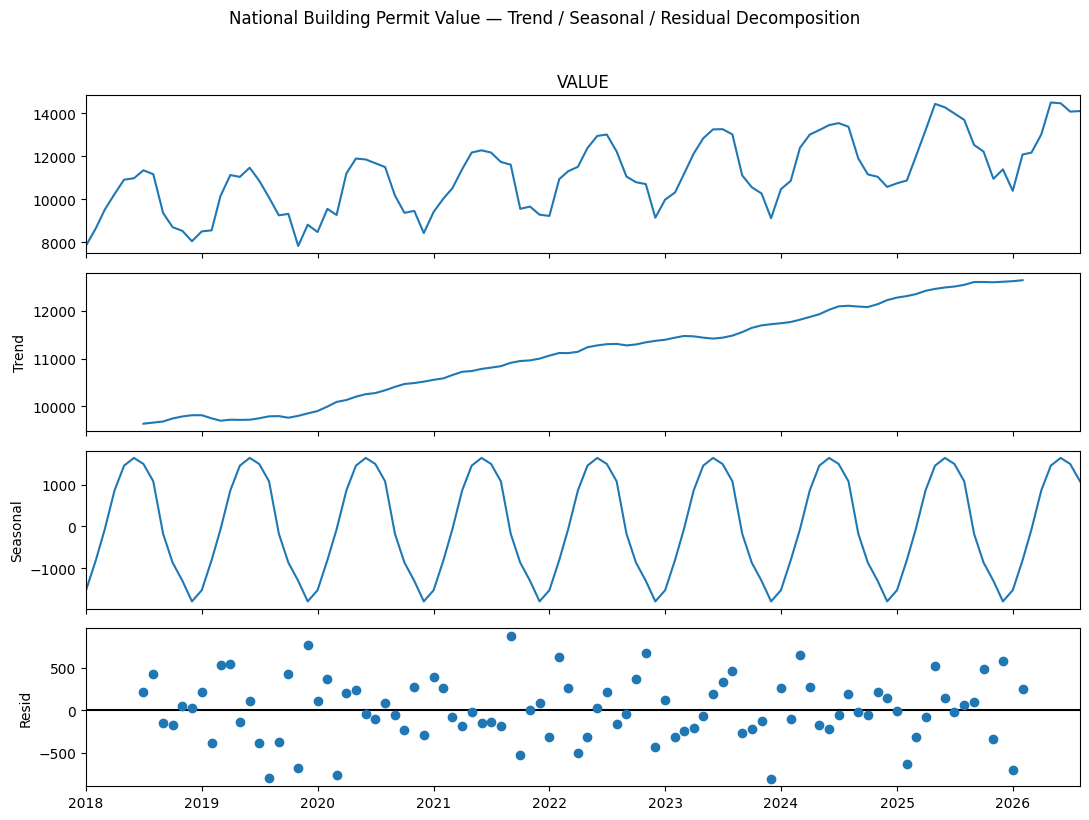

Underlying trend moved from 9,633 to 12,645 over the observed period (+31.3%).


In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = national["VALUE"].dropna()
decomposition = seasonal_decompose(series, model="additive", period=12)

fig = decomposition.plot()
fig.set_size_inches(11, 8)
fig.suptitle("National Building Permit Value — Trend / Seasonal / Residual Decomposition", y=1.02)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

trend_component = decomposition.trend.dropna()
print(f"Underlying trend moved from {trend_component.iloc[0]:,.0f} to {trend_component.iloc[-1]:,.0f} "
      f"over the observed period ({(trend_component.iloc[-1] / trend_component.iloc[0] - 1) * 100:+.1f}%).")


## 9. Analysis tool #3 — Short-term trend forecast (scikit-learn)

A simple linear regression on the trend component gives a defensible, easy-to-explain
3-month forward projection — not a sophisticated forecast, but exactly the kind of directional
estimate an analyst is asked for in a monthly reporting cycle ("are we tracking up or down
heading into next quarter").


In [9]:
from sklearn.linear_model import LinearRegression

recent = national["VALUE"].dropna().tail(24)  # last 2 years for a responsive but stable trend line
X = np.arange(len(recent)).reshape(-1, 1)
y = recent.values

model = LinearRegression()
model.fit(X, y)

future_X = np.arange(len(recent), len(recent) + 3).reshape(-1, 1)
forecast = model.predict(future_X)

future_dates = pd.date_range(recent.index[-1] + pd.DateOffset(months=1), periods=3, freq="MS")
forecast_df = pd.DataFrame({"REF_DATE": future_dates, "forecast_value": forecast.round(0)})

monthly_slope = model.coef_[0]
direction = "upward" if monthly_slope > 0 else "downward"
print(f"Trend direction: {direction} (~{monthly_slope:,.0f} per month based on the last 24 months)")
forecast_df


Trend direction: upward (~99 per month based on the last 24 months)


,REF_DATE,forecast_value
0,2026-09-01,13725.0
1,2026-10-01,13824.0
2,2026-11-01,13922.0


## 10. Regional comparison chart

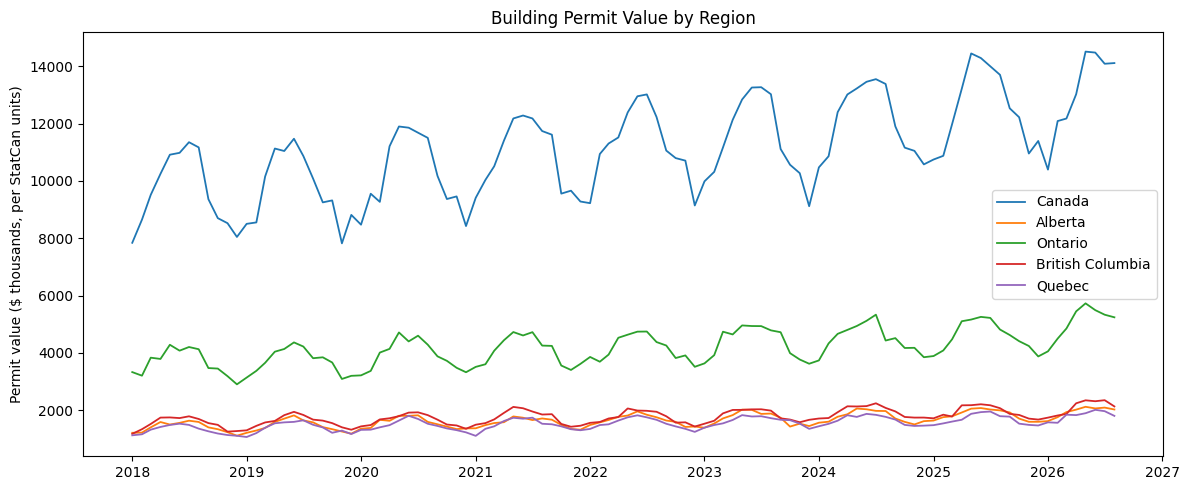

In [10]:
import matplotlib.pyplot as plt

regional = df.groupby(["REF_DATE", "GEO"])["VALUE"].sum().reset_index()

plt.figure(figsize=(12, 5))
for region in REGIONS_OF_INTEREST:
    subset = regional[regional["GEO"] == region]
    plt.plot(subset["REF_DATE"], subset["VALUE"], label=region, linewidth=1.3)

plt.legend()
plt.title("Building Permit Value by Region")
plt.ylabel("Permit value ($ thousands, per StatCan units)")
plt.tight_layout()
plt.show()


## 11. Export for SQL and Power BI

In [11]:
csv_path = "statcan_building_permits.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path} ({len(df):,} rows)")

db_path = "statcan_building_permits.db"
conn = sqlite3.connect(db_path)
df.to_sql("building_permits", conn, if_exists="replace", index=False)
national.reset_index().to_sql("national_trend", conn, if_exists="replace", index=False)
forecast_df.to_sql("forecast", conn, if_exists="replace", index=False)
conn.close()
print(f"Saved {db_path} — tables: building_permits, national_trend, forecast")


Saved statcan_building_permits.csv (1,040 rows)
Saved statcan_building_permits.db — tables: building_permits, national_trend, forecast


## 12. Summary

| Step | What happened |
|---|---|
| Pull | Called StatCan's WDS API for the live Building Permits table (34-10-0066-01) |
| Clean | Filtered to national + 4 provinces, parsed dates, dropped missing values |
| Analyze | YoY comparison (pandas), seasonal decomposition (statsmodels), 3-month forecast (scikit-learn) |
| Export | CSV + SQLite (3 tables), ready for SQL queries and Power BI |

**To make this genuinely live and recurring:**
1. Set `USE_LIVE_API = True` — no key needed, it will pull immediately
2. Since StatCan updates this table roughly monthly, schedule the notebook to re-run monthly
   via Task Scheduler (Windows) or `cron` (Mac/Linux) — see `StatCan_Tracker_Explainer.pdf`
3. Point Power BI at `statcan_building_permits.csv` with Scheduled Refresh

See `statcan_sql_setup.sql` for the schema and example queries.
